In [11]:
import subprocess
subprocess.run(['pip', 'install', 'scikit-learn'])

import warnings
warnings.filterwarnings('ignore')

In [12]:
import sys
sys.path.append('.')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from capstone import (
    load_and_prepare,
    missing_data_report,
    summarise_response_times,
    call_type_profile,
    temporal_demand_heatmap,
    response_time_regression,
    kmeans_resource_clusters,
    kde_hotspots
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

print('Environment ready.')

Environment ready.


## 1 — Data Loading & Preparation


In [13]:
df = load_and_prepare("EMS_Incident_Dispatch_Data.csv")

Loaded 3,261,463 rows x 10 columns


In [14]:
# Quick structural overview
print(f"Shape: {df.shape}")
print(f"\nColumn list:")
for col in df.columns:
    print(f"  {col:<45} {str(df[col].dtype):<12} {df[col].nunique():>8,} unique")

Shape: (3261463, 10)

Column list:
  INCIDENT_DATETIME                             datetime64[ns] 3,199,206 unique
  FINAL_CALL_TYPE                               category          169 unique
  INCIDENT_RESPONSE_SECONDS_QY                  object            999 unique
  BOROUGH                                       category            6 unique
  ZIPCODE                                       object            235 unique
  HOUR                                          int8               24 unique
  DAY_OF_WEEK                                   category            7 unique
  MONTH                                         int8               12 unique
  YEAR                                          int16               3 unique
  RESPONSE_TIME_MIN                             float64           999 unique


## 2 - Missing Data Report
Before any analysis, we characterise missingness. Columns with > 20 % missing
will require careful consideration before inclusion in statistical models. 

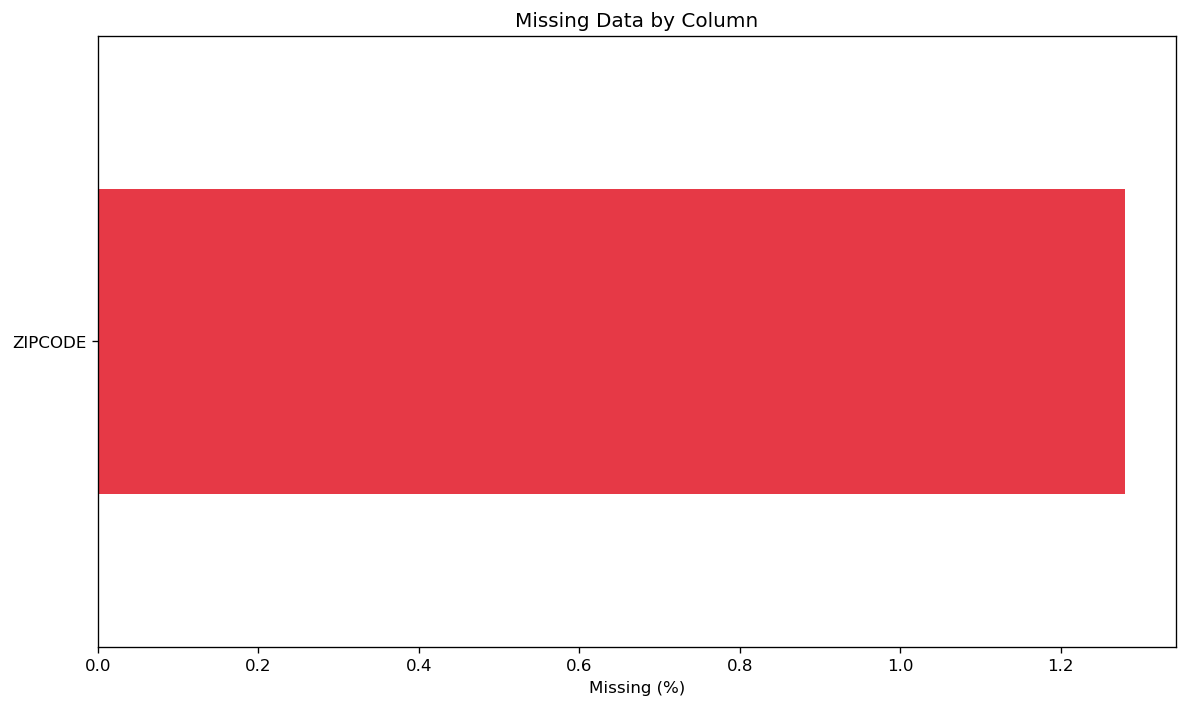

,missing_count,missing_pct
ZIPCODE,41636,1.28


In [15]:
missing_data_report(df)


## 3 - EDA

### 3.1 Incident Volume by Borough

Borough column detected: BOROUGH


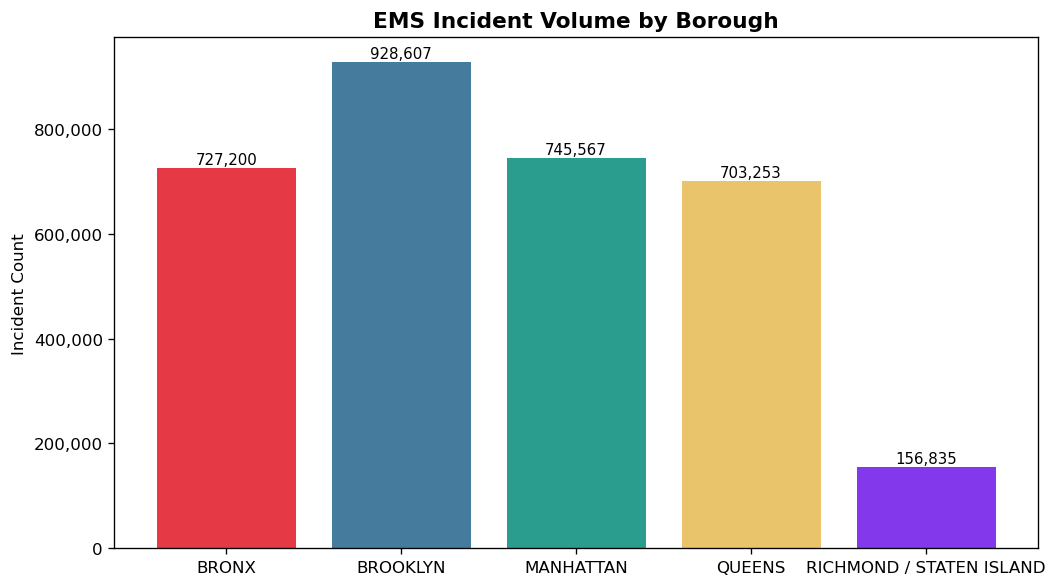

In [16]:
BOROUGH_ORDER = ['BRONX', 'BROOKLYN', 'MANHATTAN', 'QUEENS', 'RICHMOND / STATEN ISLAND']
BOROUGH_PALETTE = {
    "BRONX":         "#E63946",
    "BROOKLYN":      "#457B9D",
    "MANHATTAN":     "#2A9D8F",
    "QUEENS":        "#E9C46A",
    "RICHMOND / STATEN ISLAND": "#8338EC",
}
PLT_STYLE = "seaborn-v0_8-whitegrid"

borough_col = next((c for c in df.columns if 'BOROUGH' in c), None)
print(f"Borough column detected: {borough_col}")

borough_counts = (
    df[borough_col]
    .value_counts()
    .reindex([b for b in BOROUGH_ORDER if b in df[borough_col].unique()])
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    borough_counts.index,
    borough_counts.values,
    color=[BOROUGH_PALETTE[b] for b in borough_counts.index],
    edgecolor='white', linewidth=0.6
)
ax.set_title('EMS Incident Volume by Borough', fontsize=13, fontweight='bold')
ax.set_ylabel('Incident Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 50, f'{h:,}',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('borough_volume.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Incident Volume by Hour

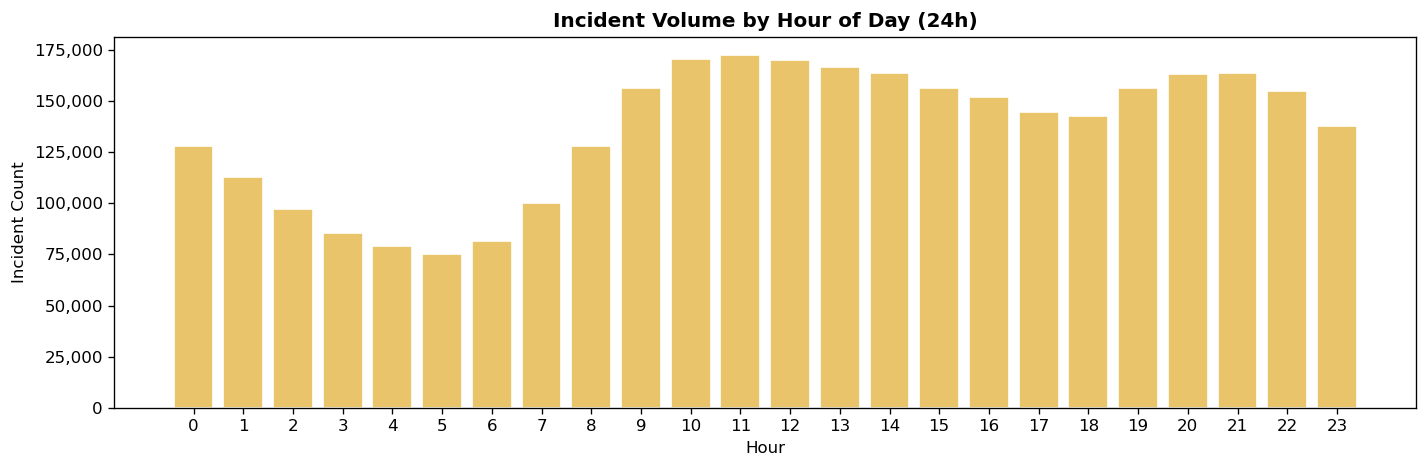

In [17]:
hourly = df['HOUR'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(hourly.index, hourly.values, color='#E9C46A', edgecolor='white')
ax.set_title('Incident Volume by Hour of Day (24h)', fontweight='bold')
ax.set_xlabel('Hour')
ax.set_ylabel('Incident Count')
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('hourly_volume.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Top 20 Call Types

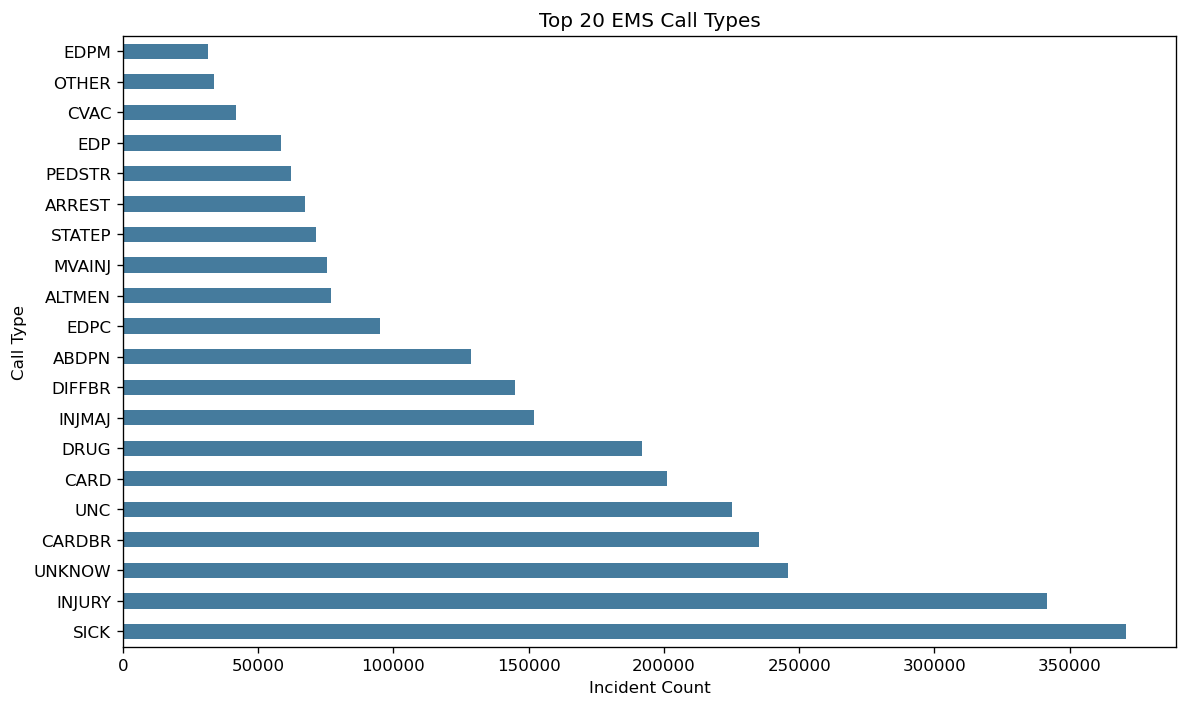

,call_type,count,percentage
0,SICK,370759,11.37
1,INJURY,341780,10.48
2,UNKNOW,245791,7.54
3,CARDBR,235233,7.21
4,UNC,225238,6.91
5,CARD,201201,6.17
6,DRUG,191707,5.88
7,INJMAJ,152010,4.66
8,DIFFBR,144937,4.44
9,ABDPN,128547,3.94


In [18]:
call_type_profile(df, call_type_col='FINAL_CALL_TYPE', top_n=20)

### 3.4 Call Volume Heatmap 

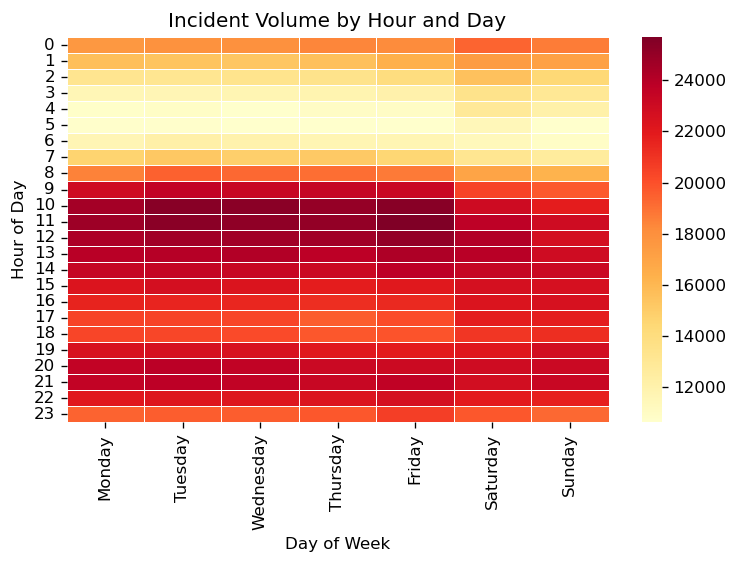

DAY_OF_WEEK,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
HOUR,,,,,,,
0,17609,17879,17933,18360,18187,19383,18662
1,15629,15402,15321,15614,16333,17439,17115
2,13255,13175,13372,13454,14011,15507,14399
3,11594,11640,11731,11830,12079,13502,12982
4,10768,10886,10632,10922,10961,12911,12109
5,10700,10693,10665,10631,10616,11480,10640
6,11624,12190,11998,11725,11690,11330,10903
7,14648,15251,14885,15194,14490,13183,12640
8,18498,19453,19242,19071,18703,17015,16260


In [19]:
temporal_demand_heatmap(df, hour_col='HOUR', day_col='DAY_OF_WEEK')

## 4 - Response Time Analysis 


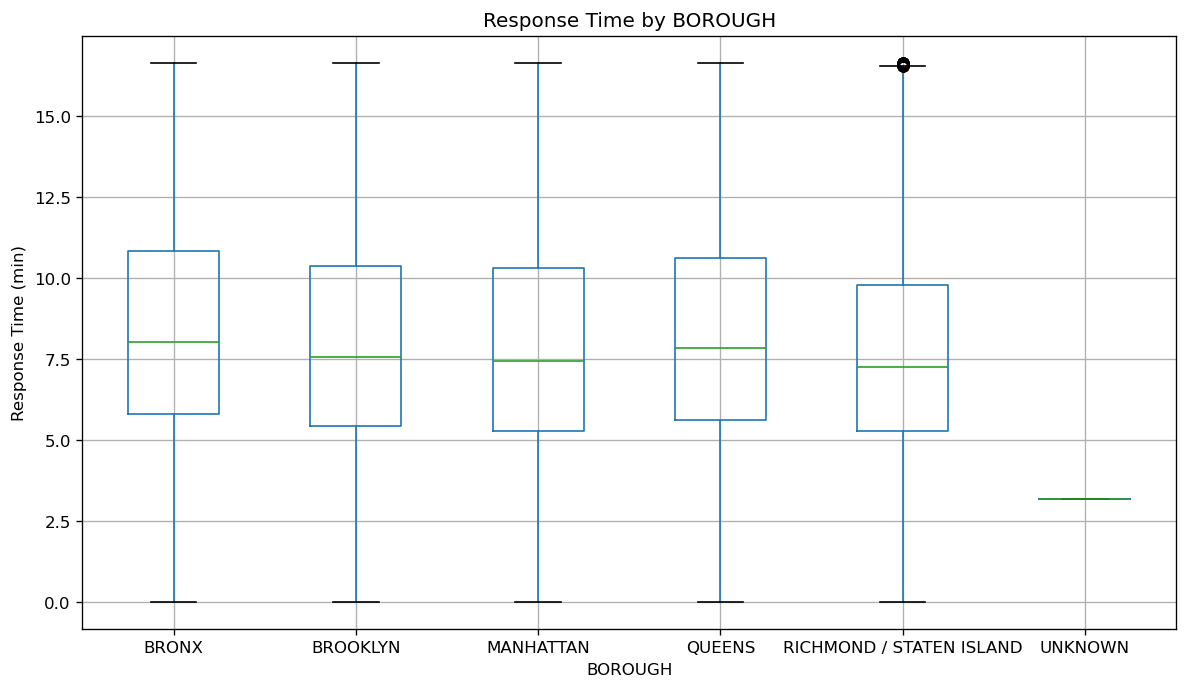

,count,mean,median,std,min,max
BOROUGH,,,,,,
UNKNOWN,1,3.20,3.20,NaN,3.20,3.20
RICHMOND / STATEN ISLAND,156835,7.73,7.25,3.28,0.02,16.65
MANHATTAN,745567,7.98,7.45,3.52,0.02,16.65
BROOKLYN,928607,8.06,7.57,3.47,0.02,16.65
QUEENS,703253,8.25,7.85,3.50,0.02,16.65
BRONX,727200,8.44,8.05,3.47,0.02,16.65


In [20]:
rt_stats = summarise_response_times(df, response_col='RESPONSE_TIME_MIN', group_by='BOROUGH')
rt_stats.sort_values('median')

## 5 Are the response time differences statistcally significant? 

In [21]:
groups = [
    df.loc[df[borough_col] == b, 'RESPONSE_TIME_MIN'].dropna().values
    for b in BOROUGH_ORDER
    if b in df[borough_col].unique()
]

h_stat, p_val = stats.kruskal(*groups)
print(f"Kruskal-Wallis H = {h_stat:.2f}, p = {p_val:.4e}")
if p_val < 0.05:
    print("→ Statistically significant difference in response times across boroughs (p < 0.05).")
    print("  Post-hoc pairwise comparisons (Mann-Whitney U with Bonferroni correction):")
    from itertools import combinations
    boroughs_present = [b for b in BOROUGH_ORDER if b in df[borough_col].unique()]
    n_comparisons = len(list(combinations(boroughs_present, 2)))
    for b1, b2 in combinations(boroughs_present, 2):
        g1 = df.loc[df[borough_col] == b1, 'RESPONSE_TIME_MIN'].dropna()
        g2 = df.loc[df[borough_col] == b2, 'RESPONSE_TIME_MIN'].dropna()
        u, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
        adj_p = min(p * n_comparisons, 1.0)   # Bonferroni
        sig = '***' if adj_p < 0.001 else ('**' if adj_p < 0.01 else ('*' if adj_p < 0.05 else 'ns'))
        print(f"  {b1:<16} vs {b2:<16}  adj-p = {adj_p:.4e}  {sig}")

Kruskal-Wallis H = 11448.46, p = 0.0000e+00
→ Statistically significant difference in response times across boroughs (p < 0.05).
  Post-hoc pairwise comparisons (Mann-Whitney U with Bonferroni correction):
  BRONX            vs BROOKLYN          adj-p = 0.0000e+00  ***
  BRONX            vs MANHATTAN         adj-p = 0.0000e+00  ***
  BRONX            vs QUEENS            adj-p = 2.7024e-223  ***
  BRONX            vs RICHMOND / STATEN ISLAND  adj-p = 0.0000e+00  ***
  BROOKLYN         vs MANHATTAN         adj-p = 8.2179e-73  ***
  BROOKLYN         vs QUEENS            adj-p = 0.0000e+00  ***
  BROOKLYN         vs RICHMOND / STATEN ISLAND  adj-p = 4.1261e-226  ***
  MANHATTAN        vs QUEENS            adj-p = 0.0000e+00  ***
  MANHATTAN        vs RICHMOND / STATEN ISLAND  adj-p = 1.6277e-94  ***
  QUEENS           vs RICHMOND / STATEN ISLAND  adj-p = 0.0000e+00  ***


In [22]:
b_time = df.groupby('BOROUGH')['RESPONSE_TIME_MIN'].median().reindex(BOROUGH_ORDER).sort_values()
print(b_time)

BOROUGH
RICHMOND / STATEN ISLAND   7.25
MANHATTAN                  7.45
BROOKLYN                   7.57
QUEENS                     7.85
BRONX                      8.05
Name: RESPONSE_TIME_MIN, dtype: float64


## 6 - Data Models

### 6.1 Multiple Linear Regression 

RMSE: 0.4163  |  R²: 0.0013

Feature Coefficients:
  BOROUGH                   -0.0106
  HOUR                      0.0013
  DAY_OF_WEEK               -0.0013
  FINAL_CALL_TYPE           0.0001


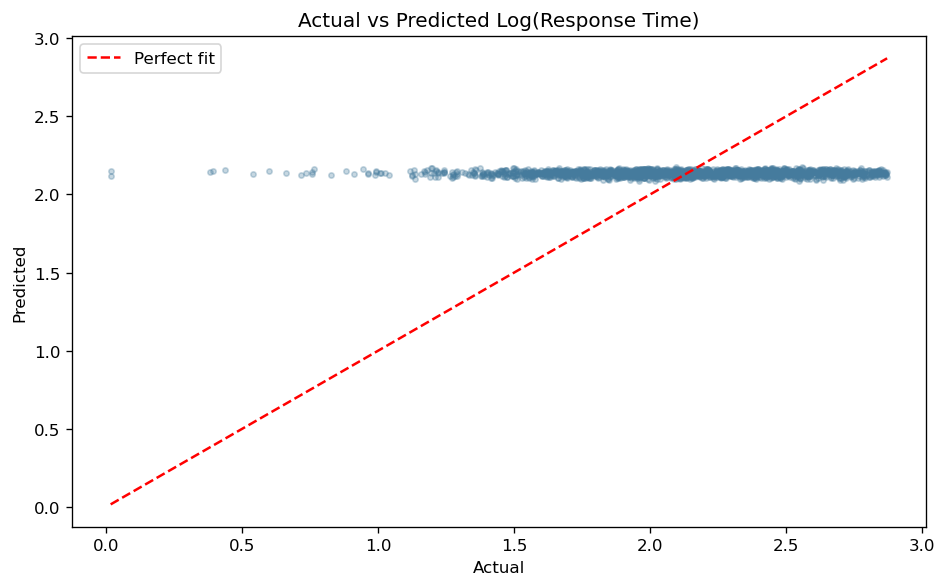

In [23]:
model, y_test, y_pred = response_time_regression(df)

### 6.2 K-Means Clustering 

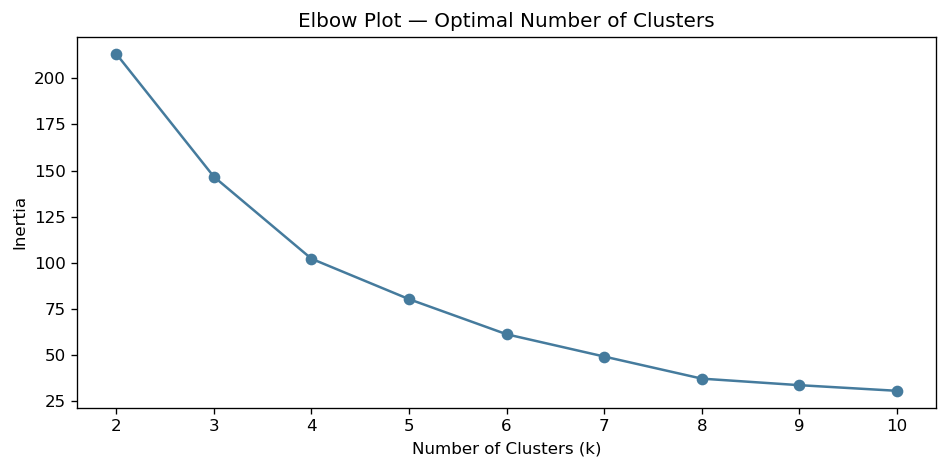


Cluster Profiles:
         avg_incidents  avg_response  peak_hour
CLUSTER                                        
0             8,799.19          7.52          3
1            37,679.68          8.25         10
2                 1.00          3.20         15
3            24,377.33          8.11          0
4             7,760.17          7.83         12


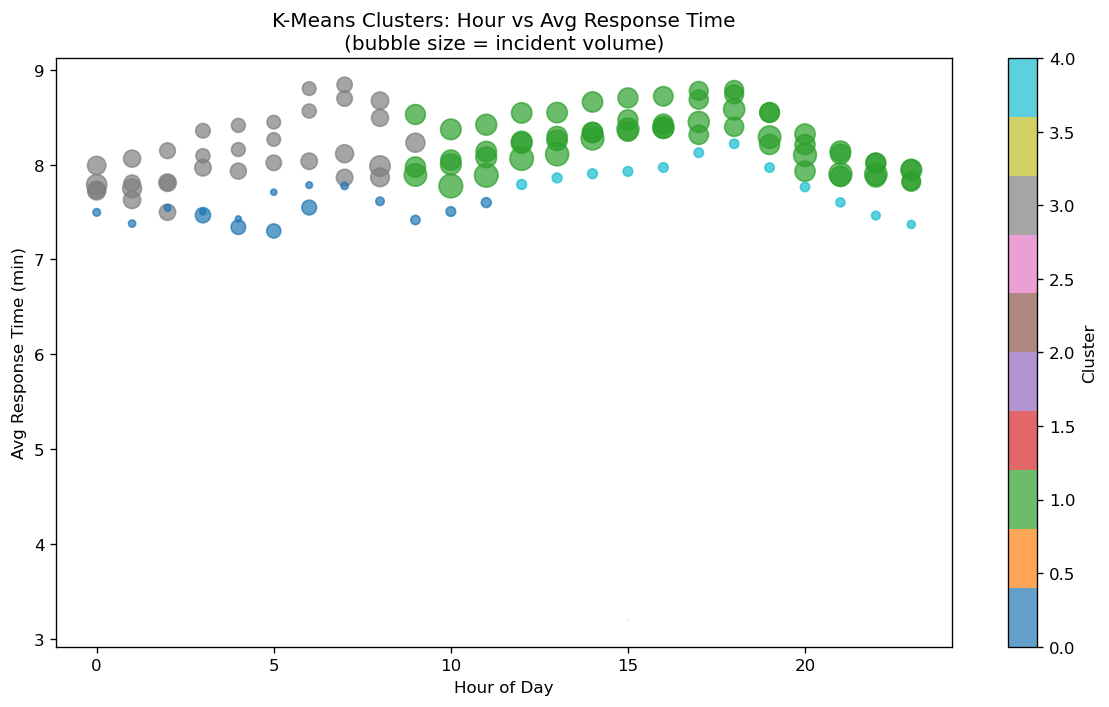

In [24]:
cluster_df, kmeans = kmeans_resource_clusters(df)


### 6.3 Kenrnel Denisty Estimation

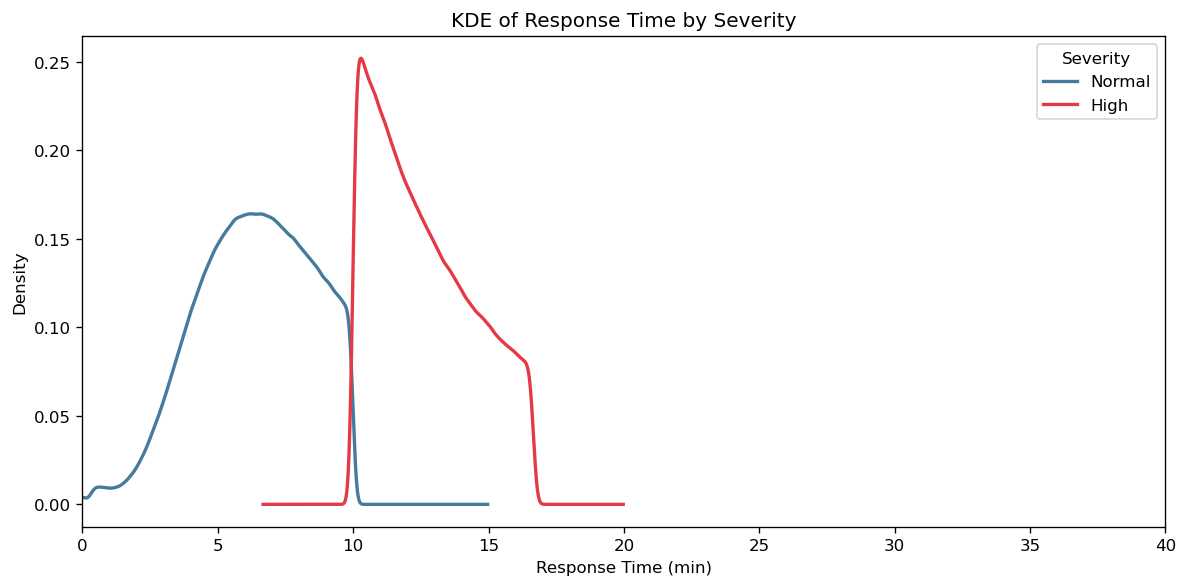

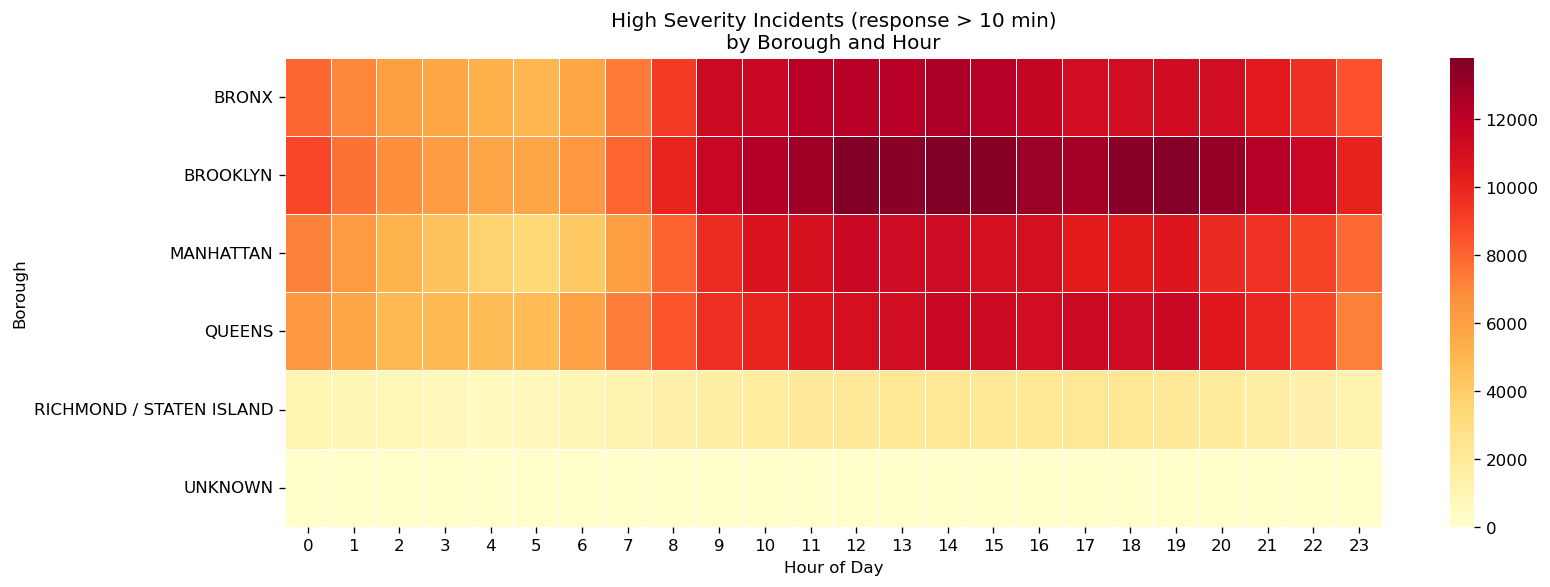


Severity breakdown:
SEVERITY
Normal    2325435
High       936028

High severity by borough:
BOROUGH
BROOKLYN                    256531
BRONX                       228523
QUEENS                      210341
MANHATTAN                   203577
RICHMOND / STATEN ISLAND     37056
UNKNOWN                          0


In [25]:
kde_df = kde_hotspots(df)